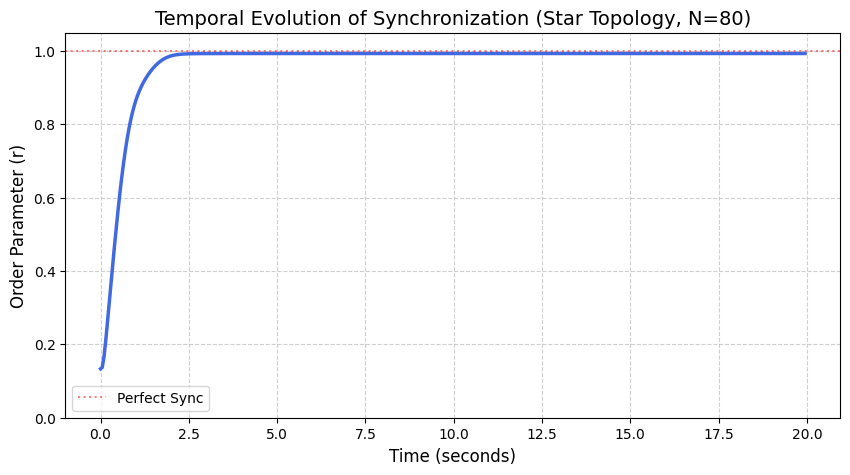

In [1]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt


num_leaves = 79
N = num_leaves + 1
G = nx.star_graph(num_leaves)

K = 2.5
Dt = 0.05
steps = 400  


np.random.seed(42)
theta = np.random.uniform(0, 2*np.pi, N)
omega = np.zeros(N)

for i in range(N):
    if i == 0:
        omega[i] = 1.5 
    else:
        omega[i] = 1.0 + np.random.uniform(-0.5, 0.5) # The Leaves


r_history = []
time_axis = np.arange(steps) * Dt


for s in range(steps):
    #r calculation
    r = np.abs(np.mean(np.exp(1j * theta)))
    r_history.append(r)
    
    d_theta = np.zeros(N)
    for i in range(N):
        neighbors = list(G.neighbors(i))
        
        coupling = sum(np.sin(theta[j] - theta[i]) for j in neighbors)
        d_theta[i] = omega[i] + (K * coupling / G.degree(i))
    
    theta += d_theta * Dt


plt.figure(figsize=(10, 5))
plt.plot(time_axis, r_history, color='royalblue', linewidth=2.5)


plt.title("Temporal Evolution of Synchronization (Star Topology, N=80)", fontsize=14)
plt.xlabel("Time (seconds)", fontsize=12)
plt.ylabel("Order Parameter (r)", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.ylim(0, 1.05)
plt.axhline(y=1.0, color='red', linestyle=':', alpha=0.5, label="Perfect Sync")
plt.legend()

plt.show()